# Hebrew Rap Understanding Benchmark (Eval & Leaderboard)

This notebook evaluates Large Language Models on their contextual comprehension of Israeli hip-hop lyrics, encompassing slang, wordplay, and complex cultural idioms.

The evaluation framework consists of three complementary paradigms:
1. **Multiple-Choice Discrimination (Closed-Form):** Evaluates whether models can identify the correct meaning among 4 contextual distractors (Accuracy & Macro F1).
2. **Dense Semantic Embedding Similarity:** Computes cosine similarity between model-generated free-form explanations and human-curated ground truth annotations using `gemini-embedding-2-preview`.
3. **LLM-as-a-Judge (Qualitative Assessment):** Evaluates semantic nuance and factual fidelity on a 5-tier rubric (0–100) using `gemini-3.8-flash`.

### Methodological Limitations & Evaluator Bias Disclosure

When interpreting benchmark standings, several architectural factors must be considered:
1. **MCQ Distractor Generation:** Multiple-choice distractor options were synthesized using `gemini-3.1-pro-preview`. Models from the Gemini family may exhibit higher familiarity with the stylistic choices, syntax distribution, or phrasing patterns of these distractors.
2. **LLM-as-a-Judge Self-Preference:** Open-ended qualitative grading is conducted via `gemini-3.8-flash`. Literature demonstrates that LLM evaluators can demonstrate an intra-family affinity (preferring linguistic formulations common to their own training distribution).
3. **Embedding Space Representation:** Vector proximity calculations rely on `gemini-embedding-2-preview`. While multilingual, the embedding geometry reflects Google's representation space.

To mitigate single-evaluator distortion, the composite index balances LLM judge grading (50%) with grounded closed-form accuracy (30%) and dense semantic similarity (20%).

In [1]:
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text
from openai import OpenAI
from openai.types.chat import ChatCompletionMessageParam
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

from models_config import GEMINI_KEY, READY_MODELS, MODEL_METADATA

# --- Plotting Configuration ---
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
        "axes.edgecolor": "#cccccc",
        "axes.linewidth": 0.8,
        "grid.color": "#e5e5e5",
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "xtick.color": "#333333",
        "ytick.color": "#333333",
    }
)


def format_display_name(clean_name: str) -> str:
    """Converts 'gemma_4_31b_it' -> 'google/gemma-4-31b-it'"""
    model_info = MODEL_METADATA.get(clean_name, {})
    creator = model_info.get("creator", "unknown")
    slug = clean_name.replace("_", "-")
    return f"{creator}/{slug}"


def plot_benchmark_leaderboard(
        df: pd.DataFrame,
        primary_col: str,
        secondary_col: str | None = None,
        title: str = "Benchmark Leaderboard",
        primary_label: str | None = None,
        secondary_label: str | None = None,
        baseline: float | None = None,
        baseline_label: str = "Baseline",
        xlim: tuple[float, float] = (0, 108),
):
    """Renders a standardized horizontal bar chart formatted for 20+ models."""
    df_sorted = df.sort_values(by=primary_col, ascending=True)
    models = df_sorted.index.tolist()
    primary_scores = df_sorted[primary_col].tolist()

    fig_height = max(5.0, len(models) * 0.45)
    fig, ax = plt.subplots(figsize=(11, fig_height), dpi=120, constrained_layout=True)
    y_indices = np.arange(len(models))

    if secondary_col and secondary_col in df_sorted.columns:
        secondary_scores = df_sorted[secondary_col].tolist()
        bar_width = 0.38

        rects1 = ax.barh(
            y_indices + bar_width / 2,
            primary_scores,
            bar_width,
            label=primary_label or primary_col,
            color="#2b5c8f",
            edgecolor="none",
        )
        ax.barh(
            y_indices - bar_width / 2,
            secondary_scores,
            bar_width,
            label=secondary_label or secondary_col,
            color="#8ab4f8",
            edgecolor="none",
        )
    else:
        bar_width = 0.62
        rects1 = ax.barh(
            y_indices,
            primary_scores,
            bar_width,
            label=primary_label or primary_col,
            color="#2b5c8f",
            edgecolor="none",
        )

    for rect in rects1:
        width = rect.get_width()
        ax.annotate(
            f"{width:.1f}",
            xy=(width, rect.get_y() + rect.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=8.5,
            color="#222222",
        )

    if baseline is not None:
        ax.axvline(
            baseline,
            color="#d9381e",
            linestyle="--",
            linewidth=1.2,
            label=baseline_label,
            zorder=3,
        )

    ax.set_xlabel("Score (%)", fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12, loc="left")
    ax.set_yticks(y_indices)
    ax.set_yticklabels(models, fontsize=9.5)
    ax.set_xlim(*xlim)
    ax.grid(axis="x", visible=True)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            loc="lower right",
            frameon=True,
            facecolor="white",
            edgecolor="#e0e0e0",
            fontsize=9,
        )

    ax.annotate(
        "* Evaluator pipeline: gemini-3.8-flash (Judge) | gemini-embedding-2-preview (Dense) | Distractors by gemini-3.1-pro",
        xy=(1.0, 0),
        xytext=(0, -42),
        xycoords="axes fraction",
        textcoords="offset points",
        ha="right",
        va="top",
        fontsize=8.5,
        color="#c0392b",
        style="italic",
    )

    plt.show()

## Part 1: Multiple-Choice Evaluation (Closed-Form)

Each evaluation item presents a song fragment, contextual stanza, and four potential interpretations (`A`, `B`, `C`, `D`).

Evaluation metrics:
* **Accuracy (%):** Strict proportion of correctly identified labels.
* **Macro F1:** Balanced macro-average across all four options, guarding against label bias.
* **Invalid Predictions:** Tracks formatting failures or non-adherence to the JSON schema.
* **Baseline:** Chance level for 4-way multiple-choice is **25.0%**.

,Rank,Params (B),Release Date,Accuracy (%),Macro F1,Valid Formats,A,B,C,D
google/gemini-3.1-pro-preview,#1,Undisclosed,2026-04,95.12,0.9435,123/123,19,33,33,38
google/gemini-3.8-flash,#2,Undisclosed,2026-08,94.31,0.9389,123/123,20,32,34,37
google/gemini-3-flash-preview,#3,Undisclosed,2025-06,92.68,0.9229,123/123,21,34,35,33
meta/muse-spark-1.3-contributor,#4,Undisclosed,2026-07,86.99,0.8639,123/123,23,33,32,35
google/gemini-3.5-flash-lite,#5,Undisclosed,2026-02,80.49,0.8010,123/123,29,33,33,28
deepseek/deepseek-v4.1-flash,#6,Undisclosed,2026-09,80.49,0.7946,123/123,24,35,29,35
openai/gpt-5,#7,Undisclosed,2025-09,79.67,0.7890,123/123,22,31,35,35
google/gemma-4-31b-it,#8,31.0,2026-05,79.67,0.7930,123/123,30,30,31,32
openai/gpt-5.6-luna,#9,Undisclosed,2026-07,79.67,0.7942,123/123,26,33,29,35
google/gemma-4-26b-a4b-it,#10,26.0,2026-05,68.29,0.6823,123/123,39,28,31,25


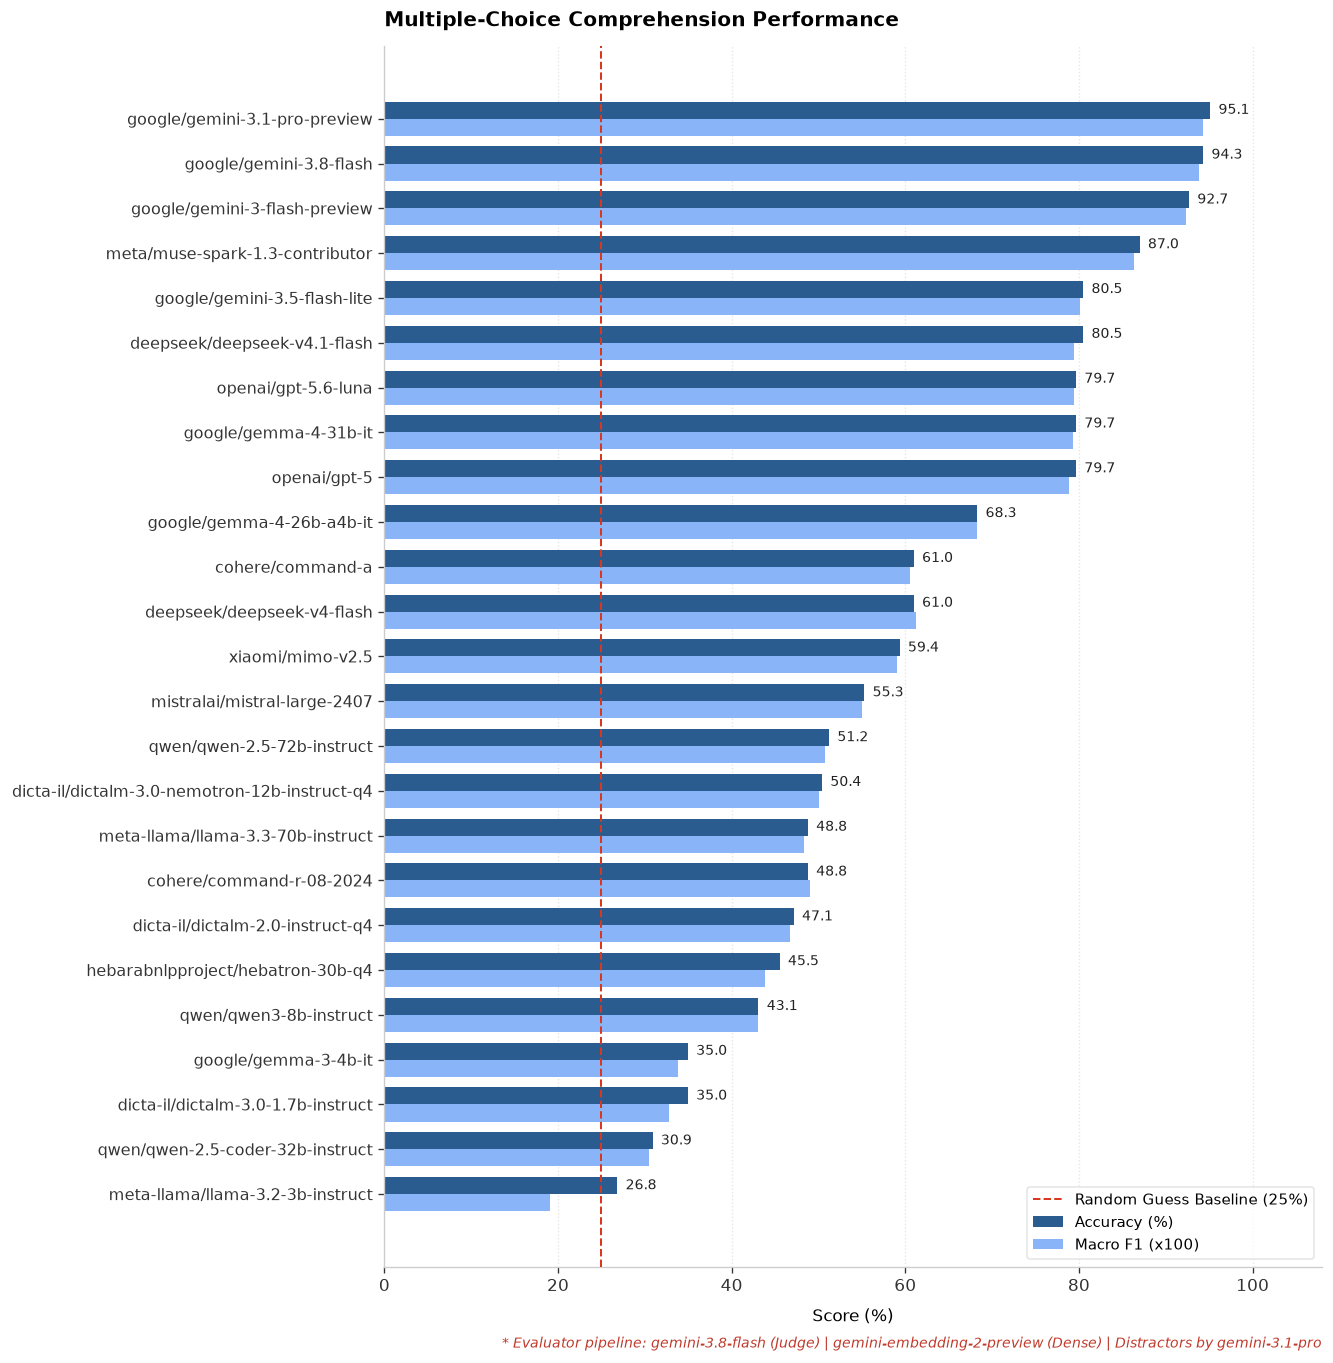

In [2]:
MC_DIR = Path("../data/results/multichoice")

HEBREW_TO_LATIN = {"א": "A", "ב": "B", "ג": "C", "ד": "D"}


def extract_option_letter(val, map_hebrew: bool = True) -> str:
    """Extracts a strict 'A', 'B', 'C', or 'D' option from model output."""
    if not val:
        return "INVALID"

    raw_str = ""
    if isinstance(val, dict):
        raw_str = str(val.get("selected_option", "")).strip()
    else:
        val_str = str(val).strip()
        try:
            parsed = json.loads(val_str)
            if isinstance(parsed, dict) and "selected_option" in parsed:
                raw_str = str(parsed["selected_option"]).strip()
        except json.JSONDecodeError:
            pass

        if not raw_str:
            match = re.search(
                r'["\']?selected_option["\']?\s*:\s*["\']?([^"\'}\s,]+)',
                val_str,
                re.IGNORECASE,
            )
            if match:
                raw_str = match.group(1).strip()
            else:
                raw_str = val_str

    candidate = raw_str.upper()

    if map_hebrew and candidate in HEBREW_TO_LATIN:
        candidate = HEBREW_TO_LATIN[candidate]

    if candidate not in {"A", "B", "C", "D"}:
        letter_match = re.search(r"\b([A-D])\b", candidate)
        if letter_match:
            candidate = letter_match.group(1)
        elif map_hebrew:
            heb_match = re.search(r"([א-ד])", raw_str)
            if heb_match:
                candidate = HEBREW_TO_LATIN.get(heb_match.group(1), "INVALID")
        else:
            candidate = "INVALID"

    return candidate if candidate in {"A", "B", "C", "D"} else "INVALID"


mc_results = {}
detailed_predictions = {}

for model_name in sorted(READY_MODELS):
    p = MC_DIR / f"{model_name}.json"
    if not p.exists():
        continue

    with p.open("r", encoding="utf-8") as f:
        records = json.load(f)

    y_true = []
    y_pred = []

    for r in records:
        gt = str(r["correct_label"]).strip().upper()
        raw_pred = r.get("predicted_label") or r["raw_model_response"]
        pred = extract_option_letter(raw_pred, map_hebrew=True)

        y_true.append(gt)
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        labels=["A", "B", "C", "D"],
        zero_division=0,
    )

    pred_series = pd.Series(y_pred)
    pred_counts = pred_series.value_counts().to_dict()
    valid_count = sum(pred_counts.get(k, 0) for k in ["A", "B", "C", "D"])

    meta = MODEL_METADATA.get(model_name, {})

    param_size = meta.get("params_b")
    display_param_size = param_size if param_size is not None else "Undisclosed"

    mc_results[model_name] = {
        "Params (B)": display_param_size,
        "Release Date": meta.get("release_date", "N/A"),
        "Accuracy (%)": round(acc * 100, 2),
        "Macro F1": round(macro_f1, 4),
        "Valid Formats": f"{valid_count}/{len(y_true)}",
        "A": pred_counts.get("A", 0),
        "B": pred_counts.get("B", 0),
        "C": pred_counts.get("C", 0),
        "D": pred_counts.get("D", 0),
    }
    detailed_predictions[model_name] = pred_series

df_mc = pd.DataFrame.from_dict(mc_results, orient="index").sort_values(
    by="Accuracy (%)",
    ascending=False,
)

df_mc.rename(index=format_display_name, inplace=True)
df_mc.insert(0, "Rank", [f"#{i + 1}" for i in range(len(df_mc))])
display(df_mc)

df_mc["Macro F1 (x100)"] = df_mc["Macro F1"] * 100

plot_benchmark_leaderboard(
    df=df_mc,
    primary_col="Accuracy (%)",
    secondary_col="Macro F1 (x100)",
    title="Multiple-Choice Comprehension Performance",
    primary_label="Accuracy (%)",
    secondary_label="Macro F1 (x100)",
    baseline=25.0,
    baseline_label="Random Guess Baseline (25%)",
)

## Part 2: Dense Semantic Embedding Similarity

This phase evaluates open-ended generation against curated ground truth interpretations.
* **Embedding Model:** `gemini-embedding-2-preview` (via OpenAI-compatible Google endpoint).
* **Caching Strategy:** Vectors are saved incrementally into compressed `.npz` archives to guarantee idempotent execution and zero API quota re-billing.
* **Metric:** Scaled Cosine Similarity ($\max(0, \cos(\theta)) \times 100$).

Loaded all 123 embeddings from ground_truth.npz.
Loaded all 123 embeddings from command_a.npz.
Loaded all 123 embeddings from command_r_08_2024.npz.
Loaded all 123 embeddings from deepseek_v4.1_flash.npz.
Loaded all 123 embeddings from deepseek_v4_flash.npz.
Loaded all 123 embeddings from dictalm_2.0_instruct_q4.npz.
Loaded all 123 embeddings from dictalm_3.0_1.7b_instruct.npz.
Loaded all 123 embeddings from dictalm_3.0_nemotron_12b_instruct_q4.npz.
Loaded all 123 embeddings from gemini_3.1_pro_preview.npz.
Loaded all 123 embeddings from gemini_3.5_flash_lite.npz.
Loaded all 123 embeddings from gemini_3.8_flash.npz.
Loaded all 123 embeddings from gemini_3_flash_preview.npz.
Loaded all 123 embeddings from gemma_3_4b_it.npz.
Loaded all 123 embeddings from gemma_4_26b_a4b_it.npz.
Loaded all 123 embeddings from gemma_4_31b_it.npz.
Loaded all 123 embeddings from gpt_5.npz.
Loaded all 123 embeddings from gpt_5.6_luna.npz.
Loaded all 123 embeddings from hebatron_30b_q4.npz.
Loaded all 123 emb

,Rank,Avg Cosine Score
openai/gpt-5,#1,78.82
meta/muse-spark-1.3-contributor,#2,78.07
openai/gpt-5.6-luna,#3,77.41
google/gemini-3.5-flash-lite,#4,77.41
deepseek/deepseek-v4.1-flash,#5,76.46
google/gemini-3-flash-preview,#6,76.28
google/gemini-3.8-flash,#7,75.97
google/gemini-3.1-pro-preview,#8,75.88
cohere/command-r-08-2024,#9,75.54
cohere/command-a,#10,75.42


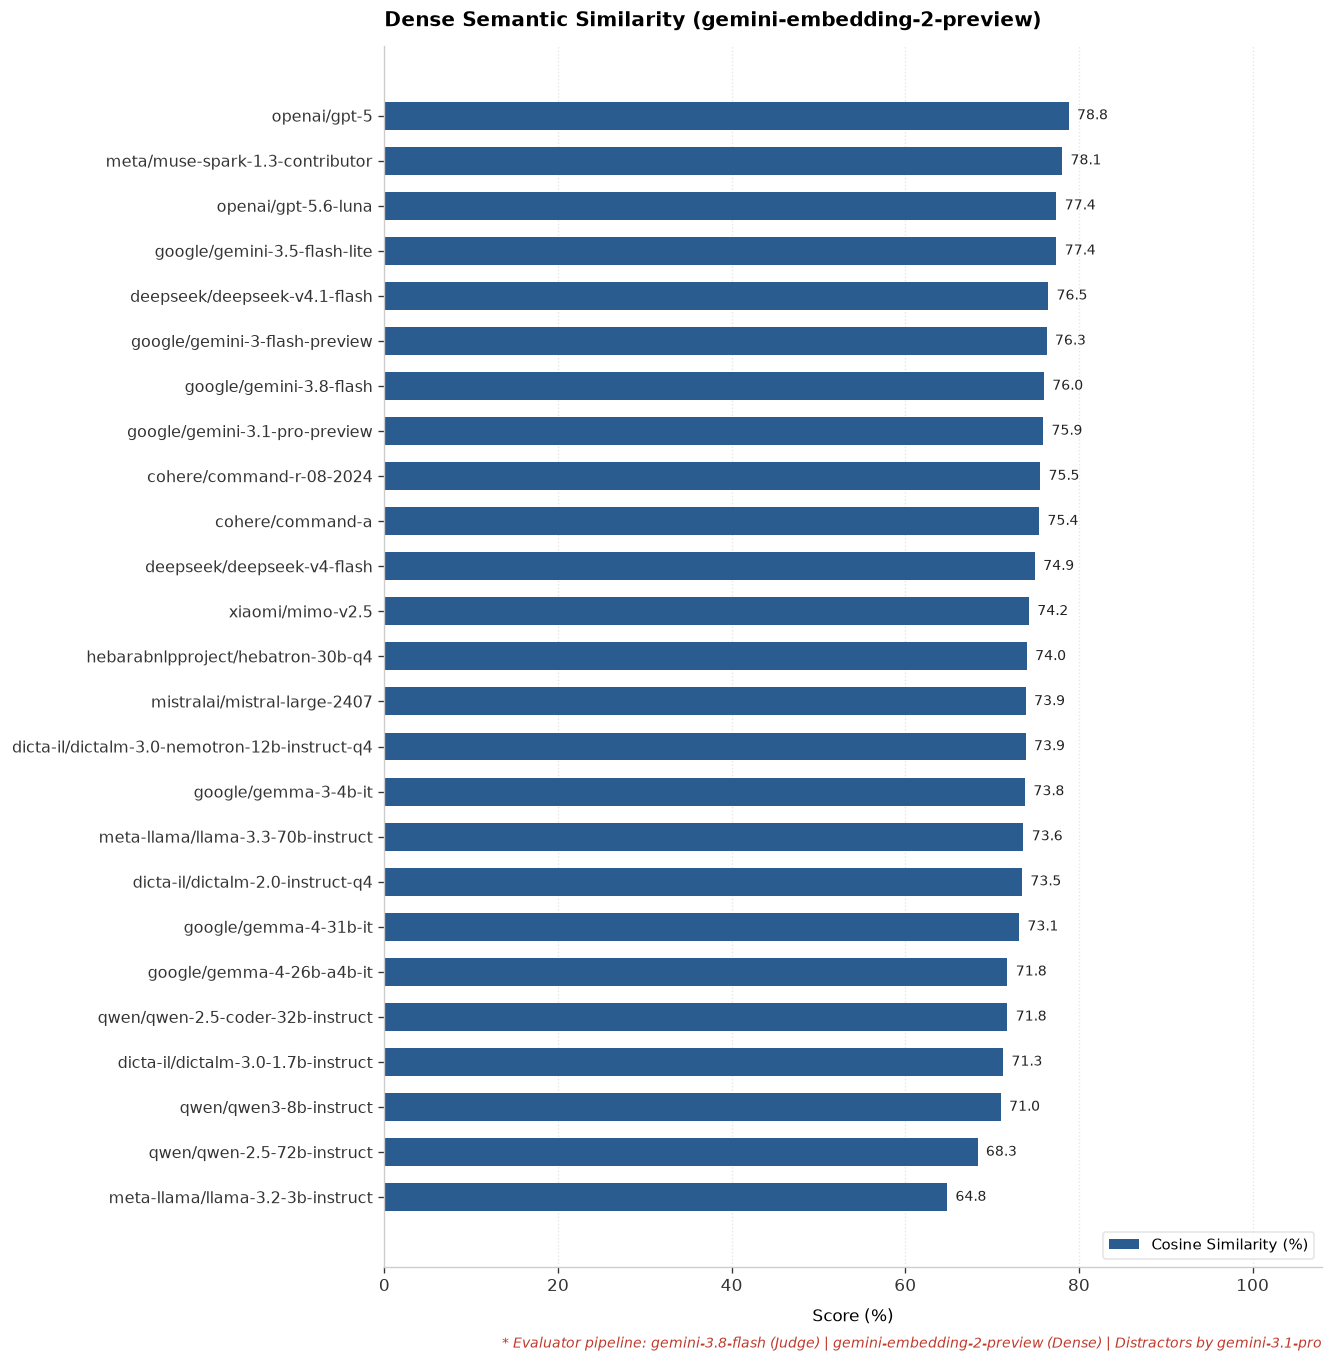

In [3]:
# 1. Paths & Initialization
OPEN_DIR = Path("../data/results/open_ended")
EMBEDDINGS_DIR = Path("../data/evaluation/cached_embeddings")
GT_EMBEDDINGS_FILE = EMBEDDINGS_DIR / "ground_truth.npz"

EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

client = OpenAI(
    api_key=GEMINI_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)


# 2. Embedding Cache Helpers
def load_cached_embeddings(npz_path: Path) -> dict[str, np.ndarray]:
    """Loads cached embeddings dictionary from an .npz archive."""
    if not npz_path.exists():
        return {}
    data = np.load(npz_path)
    ids = [str(i) for i in data["ids"]]
    vectors = data["vectors"]
    return dict(zip(ids, vectors))


def save_cached_embeddings(npz_path: Path, cache: dict[str, np.ndarray]):
    """Saves embedding dictionary to disk as a compressed .npz archive."""
    ids = list(cache.keys())
    vectors = np.array(list(cache.values()), dtype=np.float32)
    np.savez_compressed(npz_path, ids=ids, vectors=vectors)


def get_or_compute_embeddings(
        items: list[tuple[str, str]],
        target_file: Path,
        batch_size: int = 50,
) -> dict[str, np.ndarray]:
    """
    Retrieves embeddings from cache or computes missing items via the Gemini endpoint.
    Flushes to disk incrementally after each batch.
    """
    cache = load_cached_embeddings(target_file)
    missing = [(rec_id, text) for rec_id, text in items if rec_id not in cache]

    if missing:
        print(f"Computing {len(missing)} missing embeddings for {target_file.stem}...")
        for i in tqdm(
                range(0, len(missing), batch_size),
                desc=f"Embedding {target_file.stem}",
        ):
            batch = missing[i: i + batch_size]
            batch_texts = [
                text.strip() if text.strip() else " " for _, text in batch
            ]

            response = client.embeddings.create(
                model="gemini-embedding-2-preview",
                input=batch_texts,
            )

            for (rec_id, _), emb in zip(batch, response.data):
                cache[rec_id] = np.array(emb.embedding, dtype=np.float32)

            save_cached_embeddings(target_file, cache)
            time.sleep(1)
    else:
        print(f"Loaded all {len(items)} embeddings from {target_file.name}.")

    return cache


def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    a, b = np.array(vec1), np.array(vec2)
    norm_a, norm_b = np.linalg.norm(a), np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))


# 3. Load Open-Ended Results
open_results = {}
for model_name in sorted(READY_MODELS):
    path = OPEN_DIR / f"{model_name}.json"
    if not path.exists():
        continue
    with path.open("r", encoding="utf-8") as f:
        open_results[model_name] = json.load(f)

# 4. Compute or Retrieve Ground-Truth Embeddings
first_model_records = next(iter(open_results.values()))
gt_tuples = [(r["id"], r["ground_truth"]) for r in first_model_records]
gt_embeddings_map = get_or_compute_embeddings(gt_tuples, GT_EMBEDDINGS_FILE)

# 5. Compute Cosine Similarities & Update Records In-Place
similarity_scores = {}

for model_name, records in open_results.items():
    model_tuples = [(r["id"], r["raw_model_response"][:4000]) for r in records]
    model_cache_path = EMBEDDINGS_DIR / f"{model_name}.npz"
    model_embeddings_map = get_or_compute_embeddings(model_tuples, model_cache_path)

    scores = []
    for r in records:
        item_id = r["id"]
        gt_vec = gt_embeddings_map[item_id]
        resp_vec = model_embeddings_map[item_id]

        sim = cosine_similarity(gt_vec, resp_vec)
        scaled_sim = round(max(0.0, sim * 100.0), 2)
        scores.append(scaled_sim)

        r["cosine_similarity"] = scaled_sim

    # Persist annotated scores in-place
    result_path = OPEN_DIR / f"{model_name}.json"
    with result_path.open("w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    similarity_scores[model_name] = {
        "Avg Cosine Score": round(float(np.mean(scores)), 2)
    }

df_sim = pd.DataFrame.from_dict(similarity_scores, orient="index").sort_values(
    by="Avg Cosine Score",
    ascending=False,
)

df_sim.rename(index=format_display_name, inplace=True)
df_sim.insert(0, "Rank", [f"#{i + 1}" for i in range(len(df_sim))])
display(df_sim)

plot_benchmark_leaderboard(
    df=df_sim,
    primary_col="Avg Cosine Score",
    title="Dense Semantic Similarity (gemini-embedding-2-preview)",
    primary_label="Cosine Similarity (%)",
)

## Part 3: LLM-as-a-Judge Scoring (Qualitative Evaluation)

Using `gemini-3.8-flash` as an impartial linguistic judge, open-ended explanations are graded against ground-truth interpretations.
* **Grading Rubric:** Strict 5-point discrete distribution (`100` = Perfect, `75` = Minor nuance missed, `50` = Partially correct / vague, `25` = Mostly incorrect, `0` = Completely wrong / hallucination).
* **Caching:** Results and reasoning strings are saved atomically into `../data/evaluation/llm_as_a_judge_caching/`.

Judging command_a:   0%|          | 0/123 [00:00<?, ?it/s]

Judging command_r_08_2024:   0%|          | 0/123 [00:00<?, ?it/s]

Judging deepseek_v4.1_flash:   0%|          | 0/123 [00:00<?, ?it/s]

Judging deepseek_v4_flash:   0%|          | 0/123 [00:00<?, ?it/s]

Judging dictalm_2.0_instruct_q4:   0%|          | 0/123 [00:00<?, ?it/s]

...

Judging muse_spark_1.3_contributor:   0%|          | 0/123 [00:00<?, ?it/s]

Judging qwen3_8b_instruct:   0%|          | 0/123 [00:00<?, ?it/s]

Judging qwen_2.5_72b_instruct:   0%|          | 0/123 [00:00<?, ?it/s]

Judging qwen_2.5_coder_32b_instruct:   0%|          | 0/123 [00:00<?, ?it/s]

,Rank,Avg Judge Score
google/gemini-3.1-pro-preview,#1,79.27
google/gemini-3.8-flash,#2,76.22
google/gemini-3-flash-preview,#3,71.95
openai/gpt-5,#4,68.70
openai/gpt-5.6-luna,#5,64.02
meta/muse-spark-1.3-contributor,#6,62.20
deepseek/deepseek-v4.1-flash,#7,57.11
google/gemini-3.5-flash-lite,#8,56.50
google/gemma-4-31b-it,#9,48.17
cohere/command-a,#10,43.09


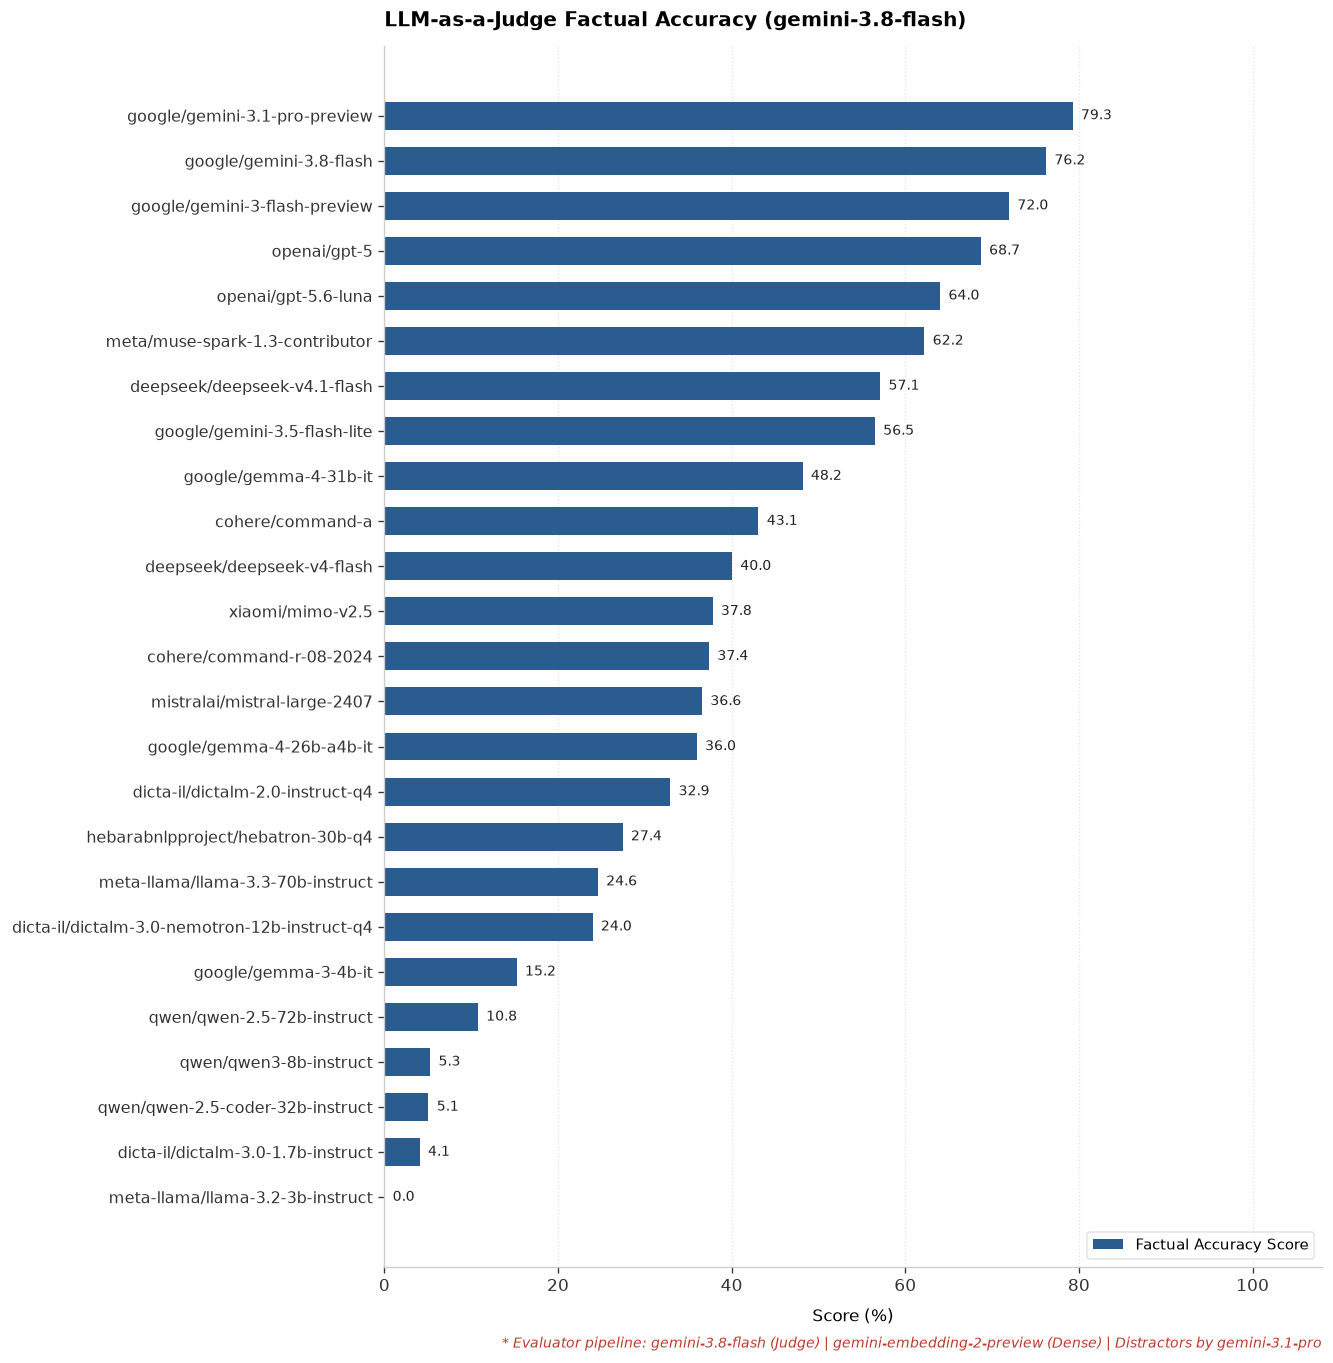

In [4]:
JUDGE_CACHE_DIR = Path("../data/evaluation/llm_as_a_judge_caching")
JUDGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

JUDGE_PROMPT_TEMPLATE = """
You are an expert linguistic judge evaluating an AI model's understanding of Israeli hip-hop slang.

You will be given a slang fragment, the ground truth explanation (what it actually means), and the AI model's predicted explanation.
Your task is to grade the AI model's explanation strictly on factual accuracy and semantic equivalence to the ground truth.

Fragment:
{fragment}

Ground Truth Explanation:
{ground_truth}

AI Model Explanation:
{model_response}

Rubric:
100: The model's explanation perfectly captures the meaning of the slang in this context.
75: The explanation is mostly correct but misses a minor nuance.
50: The explanation is partially correct but gets significant parts wrong or is too vague.
25: The explanation is mostly incorrect but has a tiny grain of truth.
0: The explanation is completely wrong, hallucinates, or is irrelevant.

Output your evaluation strictly as a JSON object with two keys:
- "score": an integer representing the grade (0, 25, 50, 75, or 100).
- "reasoning": a one-sentence justification for the score.
"""


def evaluate_single_response(
        fragment: str,
        ground_truth: str,
        model_response: str,
) -> dict:
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        fragment=fragment,
        ground_truth=ground_truth,
        model_response=str(model_response)[:4000],
    )

    messages: list[ChatCompletionMessageParam] = [
        {"role": "user", "content": prompt}
    ]
    response = client.chat.completions.create(
        model="gemini-3.8-flash",
        messages=messages,
        temperature=0.0,
        response_format={"type": "json_object"},
    )

    content = response.choices[0].message.content or "{}"
    result = json.loads(content)
    return {
        "score": int(result.get("score", 0)),
        "reasoning": str(result.get("reasoning", "Failed to parse reasoning.")),
    }


def load_judge_cache(file_path: Path) -> dict:
    if file_path.exists():
        with file_path.open("r", encoding="utf-8") as fp:
            return json.load(fp)
    return {}


def save_judge_cache(file_path: Path, cache: dict):
    with file_path.open("w", encoding="utf-8") as fp:
        json.dump(cache, fp, ensure_ascii=False, indent=2)


llm_judge_scores = {}

# Evaluate each model using open_results already stored in memory
for model_name, records in open_results.items():
    result_path = OPEN_DIR / f"{model_name}.json"
    cache_path = JUDGE_CACHE_DIR / f"{model_name}.json"

    model_cache = load_judge_cache(cache_path)
    scores = []

    for r in tqdm(records, desc=f"Judging {model_name}"):
        item_id = r["id"]

        if item_id in model_cache:
            evaluation = model_cache[item_id]
        else:
            try:
                evaluation = evaluate_single_response(
                    fragment=r["fragment"],
                    ground_truth=r["ground_truth"],
                    model_response=r["raw_model_response"],
                )
                model_cache[item_id] = evaluation
                save_judge_cache(cache_path, model_cache)
                time.sleep(2)
            except Exception as e:
                print(f"\nExecution halted on item {item_id}: {e}")
                raise e

        score = evaluation["score"]
        scores.append(score)

        r["llm_judge_score"] = score
        r["llm_judge_reasoning"] = evaluation["reasoning"]

    with result_path.open("w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    llm_judge_scores[model_name] = {
        "Avg Judge Score": round(float(np.mean(scores)), 2)
    }

df_judge = pd.DataFrame.from_dict(llm_judge_scores, orient="index").sort_values(
    by="Avg Judge Score",
    ascending=False,
)

df_judge.rename(index=format_display_name, inplace=True)
df_judge.insert(0, "Rank", [f"#{i + 1}" for i in range(len(df_judge))])
display(df_judge)

plot_benchmark_leaderboard(
    df=df_judge,
    primary_col="Avg Judge Score",
    title="LLM-as-a-Judge Factual Accuracy (gemini-3.8-flash)",
    primary_label="Factual Accuracy Score",
)

## Part 4: Composite Leaderboard & Scaling Analysis

The benchmark computes a **Composite Index** balancing distinct evaluation signals:
$$\text{Final Grade} = 0.50 \times \text{Judge Score} + 0.30 \times \text{MC Accuracy} + 0.20 \times \text{Cosine Similarity}$$

* **50% LLM Judge:** Directly evaluates semantic nuance, idiomatic equivalence, and cultural meaning.
* **30% Multiple-Choice:** Grounded, closed-form accuracy independent of LLM grading biases.
* **20% Cosine Similarity:** Dense vector proximity providing a continuous baseline comparison.


--- FINAL BENCHMARK LEADERBOARD ---


,Rank,Params (B),Release Date,MC Accuracy,Cosine Sim,Judge Score,Final Grade
google/gemini-3.1-pro-preview,#1,Undisclosed,2026-04,95.12,75.88,79.27,83.35
google/gemini-3.8-flash,#2,Undisclosed,2026-08,94.31,75.97,76.22,81.60
google/gemini-3-flash-preview,#3,Undisclosed,2025-06,92.68,76.28,71.95,79.04
openai/gpt-5,#4,Undisclosed,2025-09,79.67,78.82,68.70,74.02
meta/muse-spark-1.3-contributor,#5,Undisclosed,2026-07,86.99,78.07,62.20,72.81
openai/gpt-5.6-luna,#6,Undisclosed,2026-07,79.67,77.41,64.02,71.39
deepseek/deepseek-v4.1-flash,#7,Undisclosed,2026-09,80.49,76.46,57.11,67.99
google/gemini-3.5-flash-lite,#8,Undisclosed,2026-02,80.49,77.41,56.50,67.88
google/gemma-4-31b-it,#9,31.0,2026-05,79.67,73.11,48.17,62.61
cohere/command-a,#10,Undisclosed,2025-04,60.98,75.42,43.09,54.92


Successfully exported leaderboard to pipeline/README.md


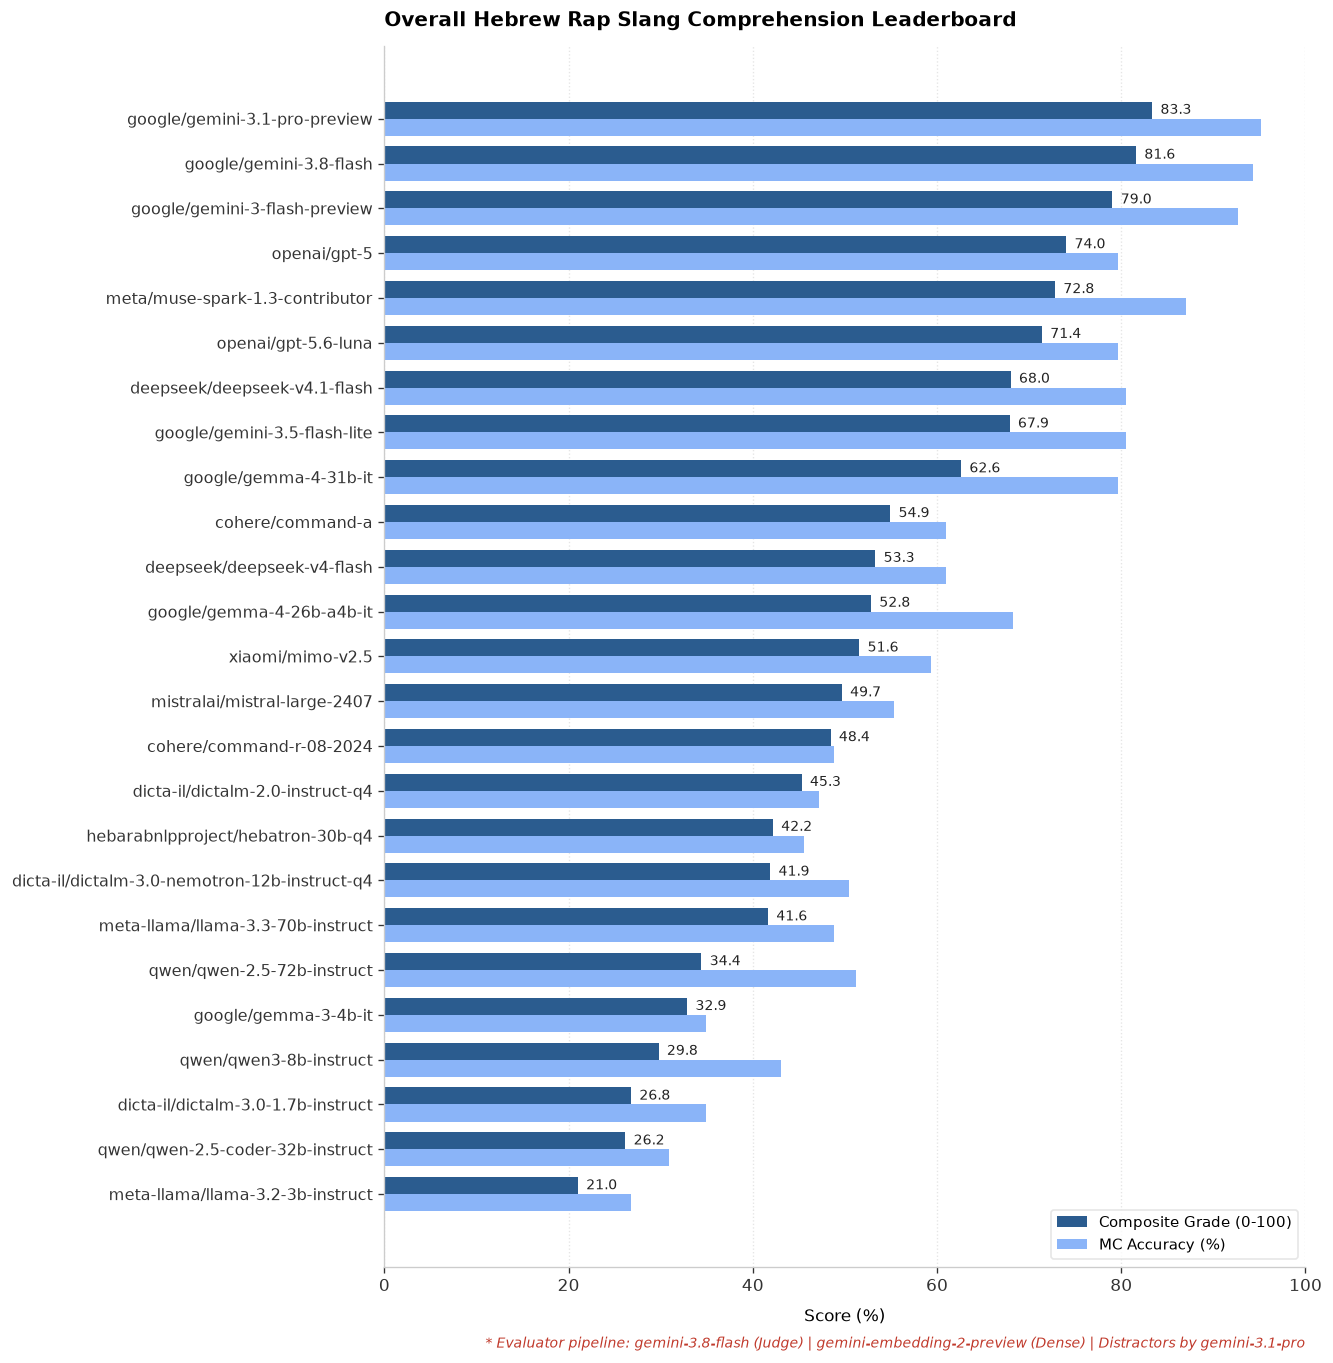

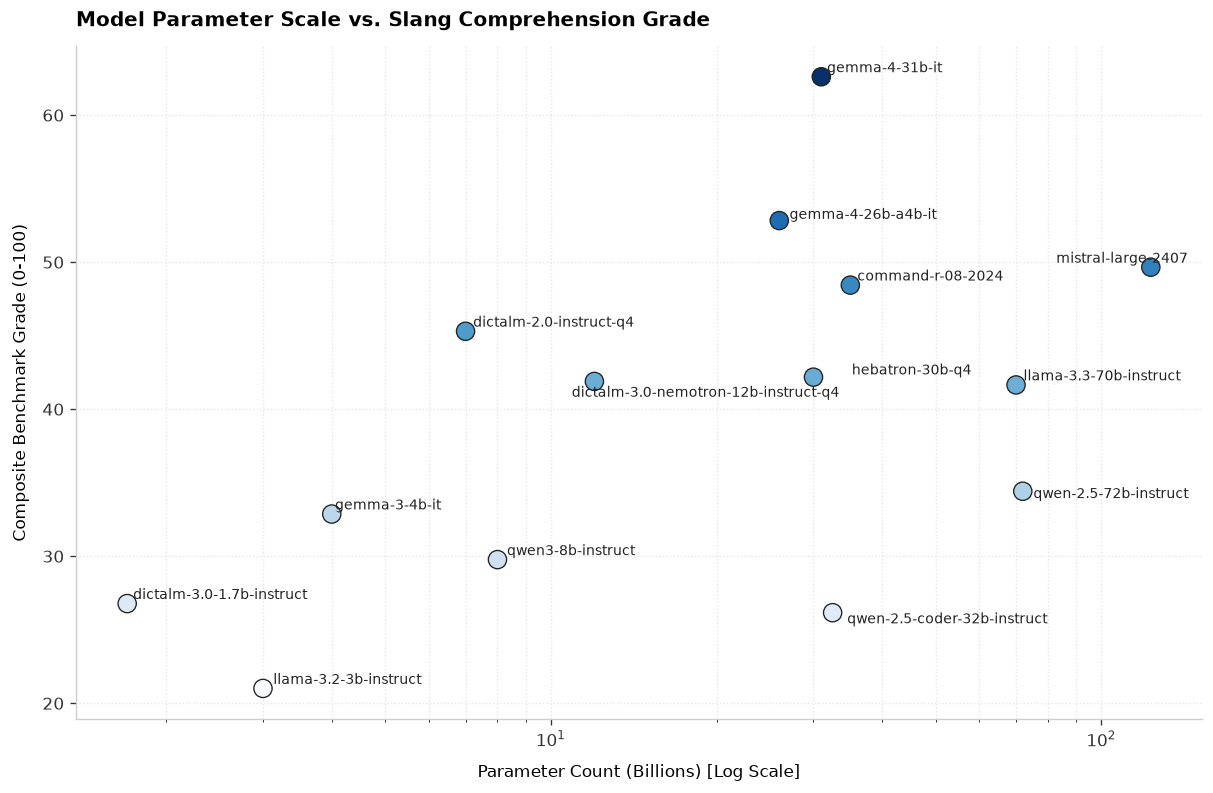

In [5]:
# 1. Merge Evaluation Results
df_final = pd.DataFrame(index=df_mc.index)

# Pull metadata
df_final["Params (B)"] = df_mc["Params (B)"]
df_final["Release Date"] = df_mc["Release Date"]
df_final["MC Accuracy"] = df_mc["Accuracy (%)"]
df_final["Cosine Sim"] = df_sim["Avg Cosine Score"]
df_final["Judge Score"] = df_judge["Avg Judge Score"]

# 2. Compute Weighted Composite Score
df_final["Final Grade"] = (
        (df_final["Judge Score"] * 0.50)
        + (df_final["MC Accuracy"] * 0.30)
        + (df_final["Cosine Sim"] * 0.20)
).round(2)

df_final = df_final.sort_values(by="Final Grade", ascending=False)
df_final.insert(0, "Rank", [f"#{i + 1}" for i in range(len(df_final))])

print("\n--- FINAL BENCHMARK LEADERBOARD ---")
display(df_final)

# Auto-Export to pipeline/README.md
readme_path = Path("README.md")
md_content = (
    "# Hebrew Rap Understanding Benchmark Leaderboard\n\n"
    "*Last updated automatically on notebook execution.*\n\n"
    f"{df_final.to_markdown(tablefmt='github')}\n"
)
readme_path.write_text(md_content, encoding="utf-8")
print("Successfully exported leaderboard to pipeline/README.md")

# 3. Main Leaderboard Bar Chart
plot_benchmark_leaderboard(
    df=df_final,
    primary_col="Final Grade",
    secondary_col="MC Accuracy",
    title="Overall Hebrew Rap Slang Comprehension Leaderboard",
    primary_label="Composite Grade (0-100)",
    secondary_label="MC Accuracy (%)",
    xlim=(0, 100),
)


# 4. Parameter Scale vs. Performance Visualization (Open-Weights Only)
def plot_parameter_scaling(df: pd.DataFrame):
    """Generates a scatter plot comparing model parameter scale to final performance."""
    df_plot = df.copy()

    # Coerce 'Undisclosed' safely back to NaN just for the plot, then drop those rows
    df_plot["Params_Num"] = pd.to_numeric(df_plot["Params (B)"], errors="coerce")
    df_plot = df_plot.dropna(subset=["Params_Num"])
    if df_plot.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 6.5), dpi=120, constrained_layout=True)

    ax.scatter(
        df_plot["Params_Num"],
        df_plot["Final Grade"],
        s=120,
        c=df_plot["Final Grade"],
        cmap="Blues",
        edgecolors="#222222",
        linewidths=0.8,
        zorder=3,
    )

    # Store text objects for adjustText
    texts = []
    for idx, row in df_plot.iterrows():
        # Strip the "creator/" prefix just for the plot label so it fits elegantly
        short_name = str(idx).split("/")[-1]
        t = ax.text(
            row["Params_Num"],
            row["Final Grade"],
            short_name,
            fontsize=8.5,
            color="#222222"
        )
        texts.append(t)

    ax.set_xscale("log")
    ax.set_xlabel("Parameter Count (Billions) [Log Scale]", fontsize=10, labelpad=8)
    ax.set_ylabel("Composite Benchmark Grade (0-100)", fontsize=10, labelpad=8)

    # Automatically resolve collisions WITHOUT drawing connection lines/arrows
    adjust_text(
        texts,
        expand_points=(1.5, 1.5),
        ax=ax
    )

    ax.set_title(
        "Model Parameter Scale vs. Slang Comprehension Grade",
        fontsize=12,
        fontweight="bold",
        pad=12,
        loc="left",
    )

    ax.grid(True, which="both", color="#e5e5e5", linestyle=":", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)

    plt.show()


plot_parameter_scaling(df_final)